In [ ]:
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "utility.py").exists():
            return p
    return start

PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"


##### import library

In [1]:
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "utility.py").exists():
            return p
    return start

PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# sys.path.append("../../../data/")

In [ ]:
from sklearn.mixture import GaussianMixture
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import utility
try:
    import pingouin as pg
except ModuleNotFoundError:
    pg = None

from pingouin import compute_effsize


##### Read file

In [ ]:
# Load all the three data and concat them to get the final result
import pandas as pd
fabZ = pd.read_csv(str(DATA_DIR / "fabZ_complete_result_kgain.csv"))
lpxC = pd.read_csv(str(DATA_DIR / "lpxC_complete_result_kgain.csv"))
murA = pd.read_csv(str(DATA_DIR / "murA_complete_result_kgain.csv"))# concat them 

final_result = pd.concat([fabZ,lpxC,murA])
final_result.drop(["FullDesignId", "Unnamed: 0"], axis=1, inplace=True)
final_result = final_result.drop_duplicates(subset=['TargetAaPosition', 'MutatedAa',
       'MutatedCodon', 'TargetAa', 'TargetCodon', 'CompetitionCoefficient',
       'fre_flank', 'alt_flank', "accumulated_gain",'GeneName'], keep="first")
final_result['CompetitionCoefficient'] = final_result['CompetitionCoefficient'].str.replace(',', '.').astype(float)
final_result['key'] = final_result['TargetAa'] + final_result['TargetAaPosition'].astype(str) + final_result['MutatedAa'] + final_result['GeneName']
final_result.head()


##### import tolerance score

In [ ]:
tol = pd.read_csv(str(DATA_DIR / "/41467_2023_35940_MOESM8_ESM.csv"))
tol['MutatedAa'] = tol['MutatedAa'].str.split(',')
tol = tol.explode('MutatedAa').reset_index(drop=True)
tol['key'] = tol['TargetAa'] + tol['TargetAaPosition'].astype(str) + tol['MutatedAa'] + tol['GeneName']
tol.head()


In [5]:
# Make key of col TargetAa TargetAaPosition and mutatedAa for fabZ_ab
# tol['key'] = tol['Residue'] + tol['Allowed substitutions'] + tol['Protein']
tol

,GeneName,TargetAa,TargetAaPosition,ToleranceScore,MutatedAa,RSA,Annotation,key
0,fabZ,T,2,0.95,A,NaN,NaN,T2AfabZ
1,fabZ,T,2,0.95,C,NaN,NaN,T2CfabZ
2,fabZ,T,2,0.95,D,NaN,NaN,T2DfabZ
3,fabZ,T,2,0.95,E,NaN,NaN,T2EfabZ
4,fabZ,T,2,0.95,F,NaN,NaN,T2FfabZ
...,...,...,...,...,...,...,...,...
13962,murA,E,419,1.00,S,NaN,NaN,E419SmurA
13963,murA,E,419,1.00,T,NaN,NaN,E419TmurA
13964,murA,E,419,1.00,V,NaN,NaN,E419VmurA
13965,murA,E,419,1.00,W,NaN,NaN,E419WmurA


##### Generate dataframe with Gene vs kGain and Tolerance score

In [6]:
tmp_gene = final_result.merge(tol.drop(["Annotation"], axis=1).drop_duplicates(), on = ['GeneName', 'TargetAa', 'TargetAaPosition', 
       'MutatedAa', 'key'], how = "left")

In [7]:
tmp_gene.head()

,GeneName,TargetAaPosition,MutatedAa,MutatedCodon,TargetAa,TargetCodon,CompetitionCoefficient,fre_flank,alt_flank,occurence,log_likelihood_gain,ref_sliding_window,alt_sliding_window,accumulated_gain,key,ToleranceScore,RSA
0,fabZ,4,A,GCG,N,AAC,0.014575,GACTACTAACACTCATA,GACTACTGCGACTCATA,6.0,0.916291,TAACACTCAT,TGCGACTCAT,2.813411,N4AfabZ,1.0,NaN
1,fabZ,4,C,TGC,N,AAC,-0.012498,GACTACTAACACTCATA,GACTACTTGCACTCATA,6.0,0.693147,TAACACTCAT,TTGCACTCAT,-3.988984,N4CfabZ,1.0,NaN
2,fabZ,4,D,GAT,N,AAC,-0.118355,GACTACTAACACTCATA,GACTACTGATACTCATA,5.0,1.871802,CTAACACTCA,CTGATACTCA,3.651139,N4DfabZ,1.0,NaN
3,fabZ,4,E,GAA,N,AAC,-0.612275,GACTACTAACACTCATA,GACTACTGAAACTCATA,5.0,1.704748,CTAACACTCA,CTGAAACTCA,2.860347,N4EfabZ,1.0,NaN
4,fabZ,4,F,TTT,N,AAC,-0.251570,GACTACTAACACTCATA,GACTACTTTTACTCATA,6.0,2.197225,TAACACTCAT,TTTTACTCAT,2.772589,N4FfabZ,1.0,NaN


##### Binarize the tolerance category with 0.8 as tolerance cut off

In [8]:
tmp_gene["tolerance_category"]  = tmp_gene["ToleranceScore"].apply(lambda x: "Tolerant" if x>=0.8 else "Intolerant")


In [9]:
tmp_gene = tmp_gene.sort_values(by='tolerance_category', ascending=False)
tmp_gene.reset_index(inplace=True, drop = True)

In [10]:
tmp_gene.head()

,GeneName,TargetAaPosition,MutatedAa,MutatedCodon,TargetAa,TargetCodon,CompetitionCoefficient,fre_flank,alt_flank,occurence,log_likelihood_gain,ref_sliding_window,alt_sliding_window,accumulated_gain,key,ToleranceScore,RSA,tolerance_category
0,fabZ,4,A,GCG,N,AAC,0.014575,GACTACTAACACTCATA,GACTACTGCGACTCATA,6.0,0.916291,TAACACTCAT,TGCGACTCAT,2.813411,N4AfabZ,1.00,NaN,Tolerant
1,murA,43,D,GAT,N,AAC,-0.415306,GATCCAGAACGTCCCGA,GATCCAGGATGTCCCGA,7.0,0.693147,AACGTCCCGA,GATGTCCCGA,-1.422764,N43DmurA,0.97,19.96,Tolerant
2,murA,37,M,ATG,E,GAA,-0.011043,GGCGGAAGAACCGGTAG,GGCGGAAATGCCGGTAG,4.0,1.734601,GAAGAACCGG,GAAATGCCGG,1.934860,E37MmurA,1.00,49.33,Tolerant
3,murA,37,N,AAC,E,GAA,0.080195,GGCGGAAGAACCGGTAG,GGCGGAAAACCCGGTAG,4.0,1.609438,GAAGAACCGG,GAAAACCCGG,2.664477,E37NmurA,1.00,49.33,Tolerant
4,murA,37,P,CCG,E,GAA,0.214157,GGCGGAAGAACCGGTAG,GGCGGAACCGCCGGTAG,5.0,1.029619,AAGAACCGGT,AACCGCCGGT,1.779444,E37PmurA,1.00,49.33,Tolerant


##### Plot median kGain heatmap (fig 6a) and tolerance score heatmap (fig 6b)

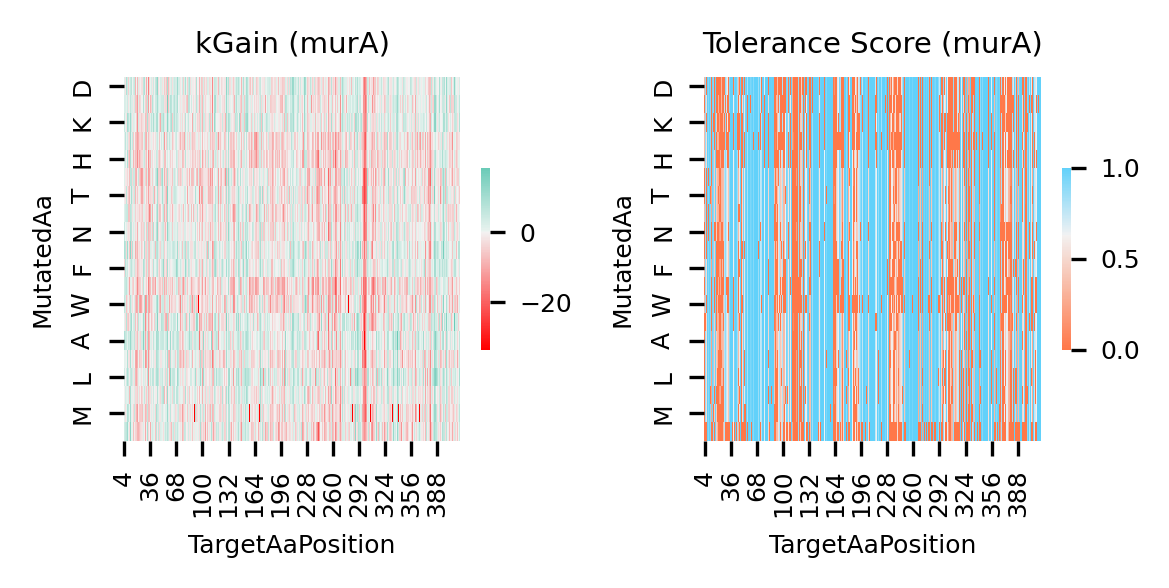

In [11]:
plt.rcParams.update({
    "axes.titlesize": 8,       # Font size of axes titles
    "axes.labelsize": 6,        # Font size of x and y labels
    "xtick.labelsize": 6,       # Font size of x-axis tick labels
    "ytick.labelsize": 6,       # Font size of y-axis tick labels
    "legend.fontsize": 8,       # Font size of legend
    "font.size": 8,
    "axes.edgecolor": "lightgray",  # Lighter axis lines
    "grid.color": "lightgray",     # Lighter grid
    "figure.facecolor": "white",   # Lighter background
})

fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=300)  # Adjust subplot for one gene

cmap_kgain = sns.diverging_palette(25, 180, l=50, s=400, as_cmap=True)
cmap_tolerance = sns.diverging_palette(20, 240, l=70, s=150, as_cmap=True)

# Define amino acid order
amino_acid_order = ["D", "E", "K", "R", "H", "S", "T", "C", "N", "Q", "F", "Y", "W", "G", "A", "V", "L", "I", "M", "P"]

# Filter data for the specific gene: murA
gene = "murA"
df_gene = tmp_gene[tmp_gene["GeneName"] == gene]

# Aggregate data to handle duplicates
df_agg = (
    df_gene.groupby(["MutatedAa", "TargetAaPosition"], as_index=False)
    .agg(
        accumulated_gain=("accumulated_gain", "median"),
        ToleranceScore=("ToleranceScore", "median"),
    )
)

df_agg["MutatedAa"] = pd.Categorical(df_agg["MutatedAa"], categories=amino_acid_order, ordered=True)

# Pivot for the heatmaps
heatmap_data_gain = df_agg.pivot(index="MutatedAa", columns="TargetAaPosition", values="accumulated_gain")
heatmap_data_tolerance = df_agg.pivot(index="MutatedAa", columns="TargetAaPosition", values="ToleranceScore")

# Fill NaN values with the minimum value of the dataset
heatmap_data_gain = heatmap_data_gain.fillna(heatmap_data_gain.min().min())
heatmap_data_tolerance = heatmap_data_tolerance.fillna(heatmap_data_tolerance.min().min())


# Adjust center for ToleranceScore based on its data range
tolerance_center = heatmap_data_tolerance.stack().mean()  # Use the mean as the center

# Heatmap for kGain
sns.heatmap(
    heatmap_data_gain,
    cmap=cmap_kgain,
    linecolor="gray",
    ax=axes[0],
    cbar_kws={"shrink": 0.5},
    center=0
)
axes[0].set_title(f"kGain ({gene})", fontsize=7)

# Heatmap for ToleranceScore
axes[1] = sns.heatmap(
    heatmap_data_tolerance,
    cmap=cmap_tolerance,
    linecolor="gray",
    ax=axes[1],
    cbar_kws={"shrink": 0.5},
    center=tolerance_center ,
)
axes[1].set_title(f"Tolerance Score ({gene})", fontsize=7)
plt.tight_layout()
plt.show()


##### fig 6c, fig 6d, fig 6e: kGain vs tolerance category

,GeneName,p_raw,d,ci_low,ci_high,p_adj
0,fabZ,2.076140e-02,0.181148,0.028632,0.297449,2.076140e-02
1,lpxC,7.109423e-09,0.169343,0.061235,0.276513,2.132827e-08
2,murA,5.460220e-08,0.129516,0.055574,0.229543,8.190329e-08


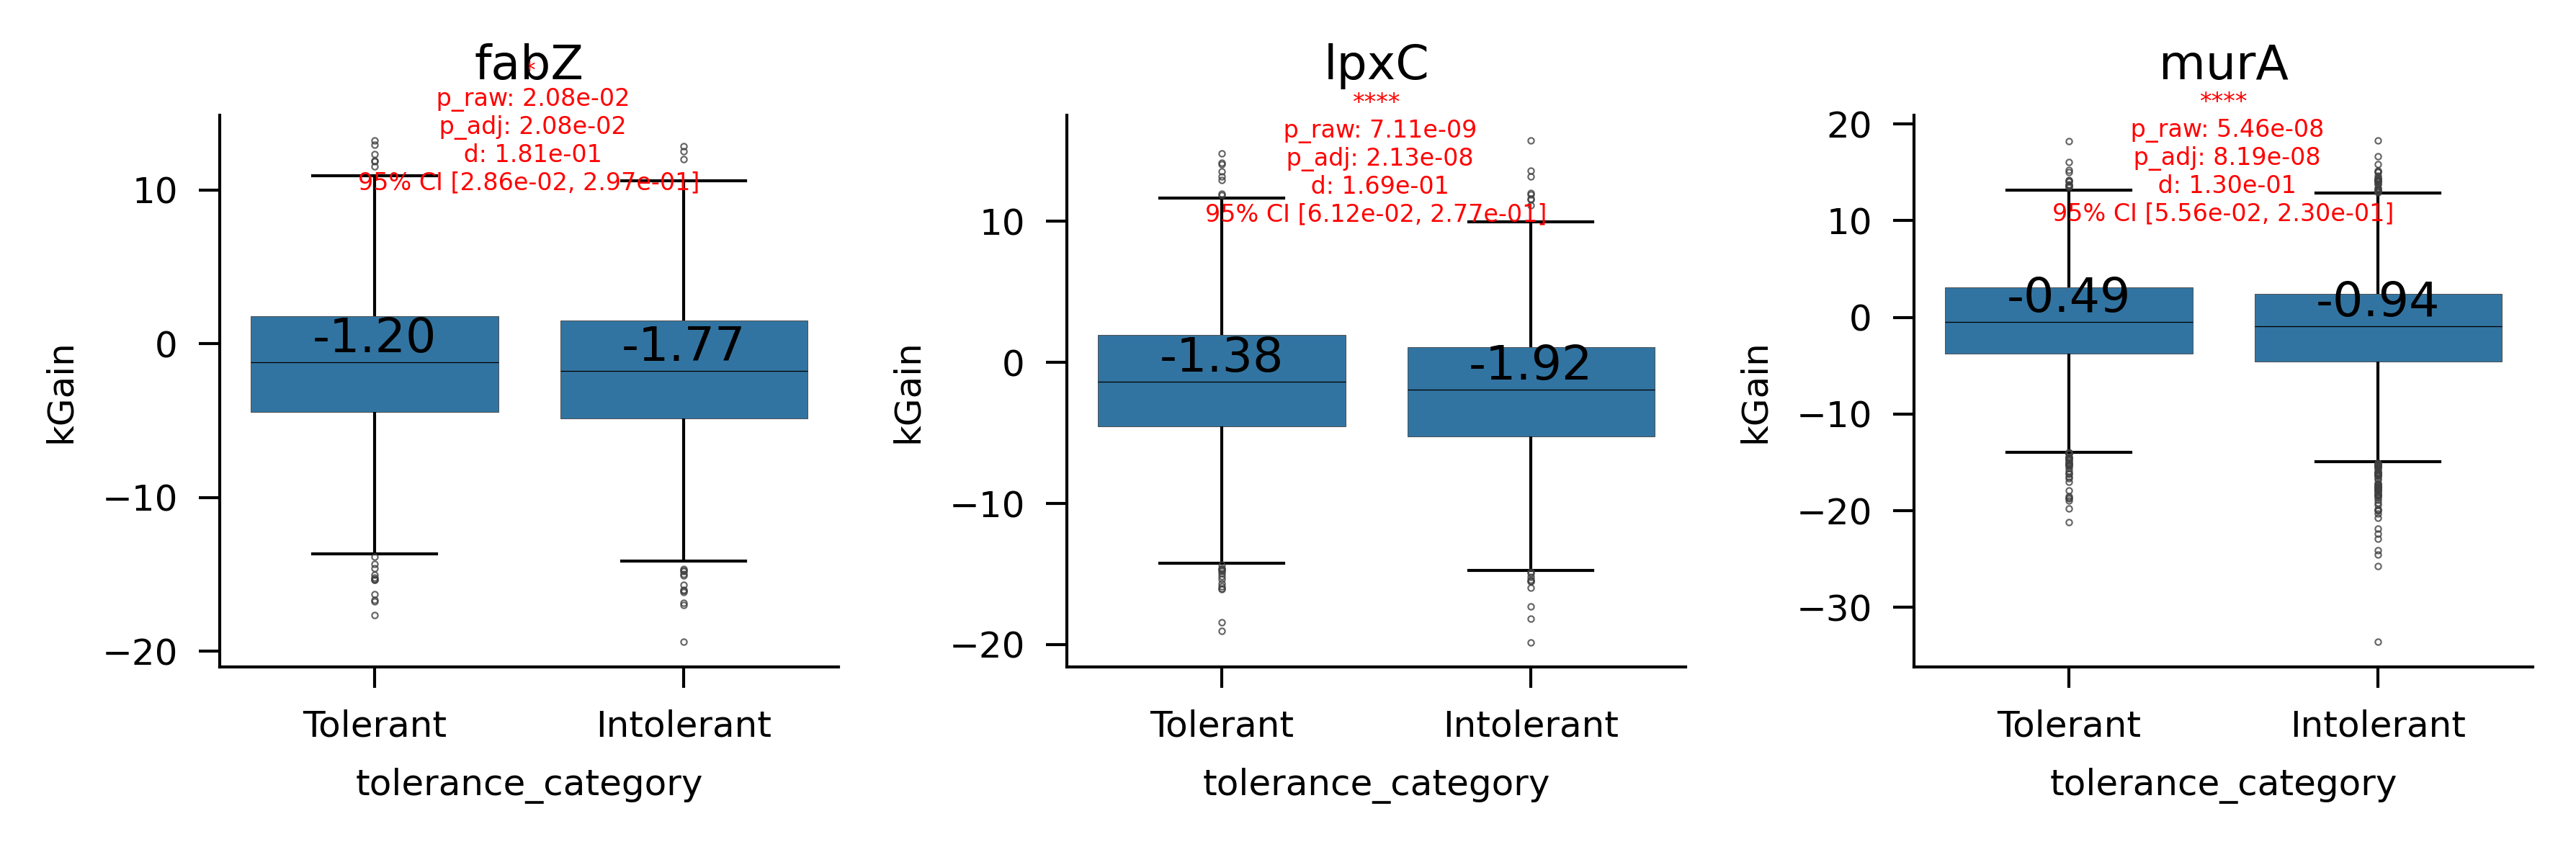

In [16]:
from statsmodels.stats.multitest import multipletests

fig, axes = plt.subplots(1, 3, figsize=(6, 2), dpi=600)

gene_order = sorted(tmp_gene["GeneName"].dropna().unique())

# Compute per-gene raw stats first, then apply family-wise BH correction
stats_rows = []
for gene_name in gene_order:
    tmp = tmp_gene[tmp_gene["GeneName"] == gene_name]
    g1 = tmp[tmp["tolerance_category"] == "Tolerant"]["accumulated_gain"]
    g2 = tmp[tmp["tolerance_category"] == "Intolerant"]["accumulated_gain"]

    p_raw = utility.man_whiteney(g1, g2, alternative="greater")
    d_value, ci_low, ci_high = utility.median_based_distance_ci(g1, g2)

    stats_rows.append({
        "GeneName": gene_name,
        "p_raw": p_raw,
        "d": d_value,
        "ci_low": ci_low,
        "ci_high": ci_high,
    })

stats_df = pd.DataFrame(stats_rows)
_, p_adj, _, _ = multipletests(stats_df["p_raw"].values, method="fdr_bh")
stats_df["p_adj"] = p_adj

for c, gene_name in enumerate(gene_order):
    tmp = tmp_gene[tmp_gene["GeneName"] == gene_name]

    axes[c].set_title(gene_name, fontsize=8)
    axes[c] = sns.boxplot(
        data=tmp,
        x='tolerance_category',
        y='accumulated_gain',
        ax=axes[c],
        linewidth=0.1,
        whiskerprops=dict(color="black", linewidth=0.5),
        capprops=dict(color="black", linewidth=0.5),
        medianprops=dict(color="black", linewidth=0.15),
        flierprops=dict(marker="o", color="black", markersize=0.25, alpha=0.8),
        dodge=True,
    )

    medians = tmp.groupby("tolerance_category")["accumulated_gain"].median()
    for idx, category in enumerate(["Tolerant", "Intolerant"]):
        if category in medians.index:
            axes[c].text(
                idx,
                medians[category],
                f'{medians[category]:.2f}',
                ha='center',
                va='bottom',
                fontsize=8,
                color="black",
            )

    res = stats_df[stats_df["GeneName"] == gene_name].iloc[0]
    star = utility.get_significance_star(res["p_adj"])
    axes[c].text(
        0.5,
        10,
        f"{star}\n p_raw: {res['p_raw']:.2e}\n p_adj: {res['p_adj']:.2e}\n d: {res['d']:.2e}\n95% CI [{res['ci_low']:.2e}, {res['ci_high']:.2e}]",
        ha="center",
        fontsize=4,
        color="red",
    )

    axes[c] = utility.custom_figure_axis(axes[c], fontsize=6, show_ticks=True, rotation=0)
    axes[c].set_ylabel("kGain")

plt.tight_layout()
stats_df


In [15]:
# Print compact stats summary
for _, r in stats_df.iterrows():
    print(
        f"{r['GeneName']}: "
        f"raw_p={r['p_raw']:.2e}, "
        f"p_adj={r['p_adj']:.2e}, "
        f"d={r['d']:.2e}, "
        f"95% CI [{r['ci_low']:.2e}, {r['ci_high']:.2e}]"
    )

# Optional: nice table output in notebook
stats_df_display = stats_df.copy()
stats_df_display["95% CI"] = stats_df_display.apply(
    lambda r: f"[{r['ci_low']:.2e}, {r['ci_high']:.2e}]", axis=1
)
display(stats_df_display[["GeneName", "p_raw", "p_adj", "d", "95% CI"]])


fabZ: raw_p=2.08e-02, p_adj=2.08e-02, d=1.81e-01, 95% CI [2.86e-02, 2.97e-01]
lpxC: raw_p=7.11e-09, p_adj=2.13e-08, d=1.69e-01, 95% CI [6.12e-02, 2.77e-01]
murA: raw_p=5.46e-08, p_adj=8.19e-08, d=1.30e-01, 95% CI [5.56e-02, 2.30e-01]


,GeneName,p_raw,p_adj,d,95% CI
0,fabZ,2.076140e-02,2.076140e-02,0.181148,"[2.86e-02, 2.97e-01]"
1,lpxC,7.109423e-09,2.132827e-08,0.169343,"[6.12e-02, 2.77e-01]"
2,murA,5.460220e-08,8.190329e-08,0.129516,"[5.56e-02, 2.30e-01]"
